Install & Imports

In [3]:
!pip install -q kagglehub tensorflow opencv-python matplotlib seaborn scikit-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

Download Dataset

In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download("fernando2rad/x-ray-lung-diseases-images-9-classes")
print("Downloaded to:", dataset_path)

100%|██████████| 182M/182M [00:05<00:00, 36.4MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/fernando2rad/x-ray-lung-diseases-images-9-classes/versions/1


Fix Dataset Path

In [5]:
def find_dataset_root(path):
    for root, dirs, files in os.walk(path):
        if len(dirs) > 2:
            return root
    return path

DATASET_PATH = find_dataset_root(dataset_path)

print("Final path:", DATASET_PATH)
print("Classes:", os.listdir(DATASET_PATH))

Final path: /root/.cache/kagglehub/datasets/fernando2rad/x-ray-lung-diseases-images-9-classes/versions/1
Classes: ['01 Processos Inflamatórios Pulmonares (Pneumonia)', '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)', '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)', '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)', '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)', '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)', '00 Anatomia Normal', '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)', '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)']


Build DataFrame

In [6]:
def build_dataframe(data_dir):
    filepaths = []
    labels = []

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for img in os.listdir(class_path):
                filepaths.append(os.path.join(class_path, img))
                labels.append(class_name)

    return pd.DataFrame({"filepath": filepaths, "label": labels})

df = build_dataframe(DATASET_PATH)
print("Total images:", len(df))
df.head()

Total images: 6743


,filepath,label
0,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
1,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
2,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
3,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
4,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)


Data Preprocessing

In [7]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()
df = df[df['filepath'].apply(os.path.exists)]

print("After cleaning:", len(df))

Missing values:
 filepath    0
label       0
dtype: int64
Duplicates: 0
After cleaning: 6743


EDA (Distribution)

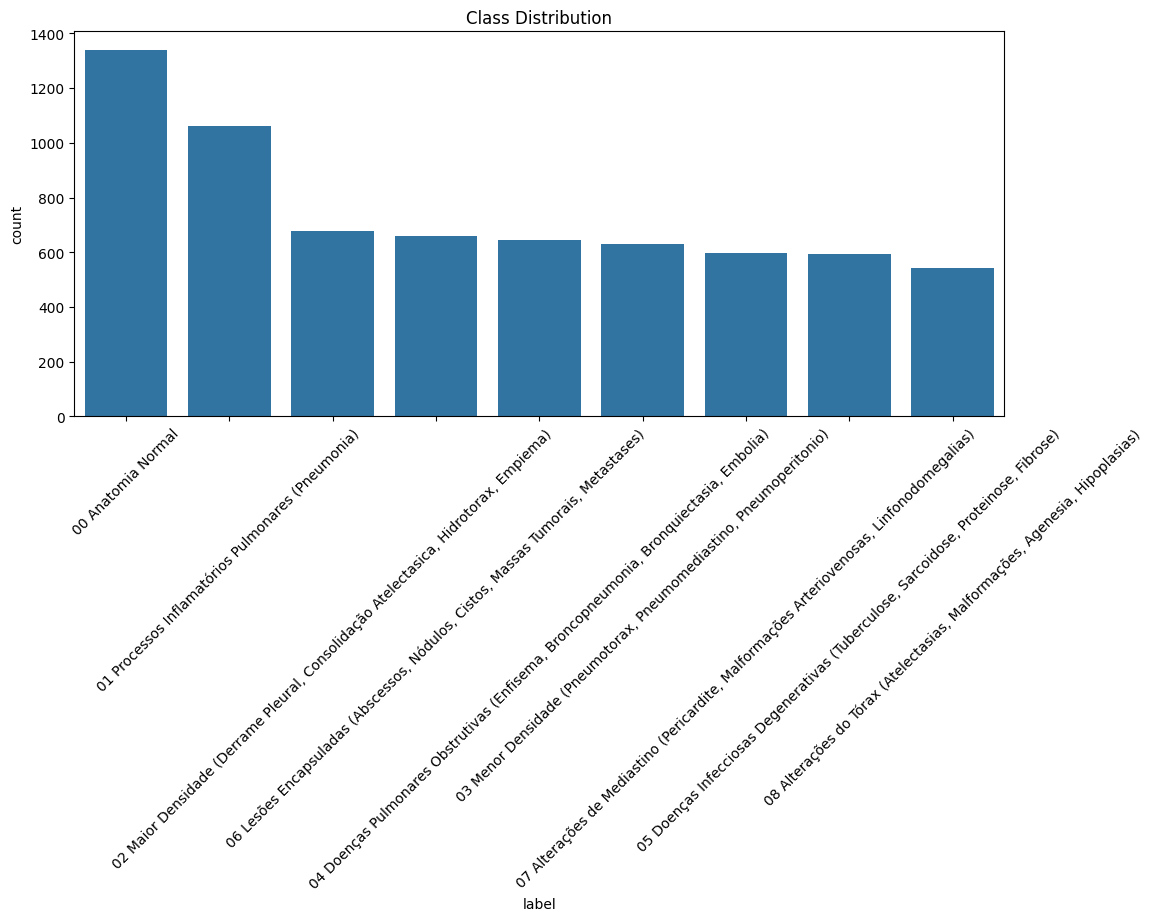

In [8]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="label", order=df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

EDA (Sample Images)

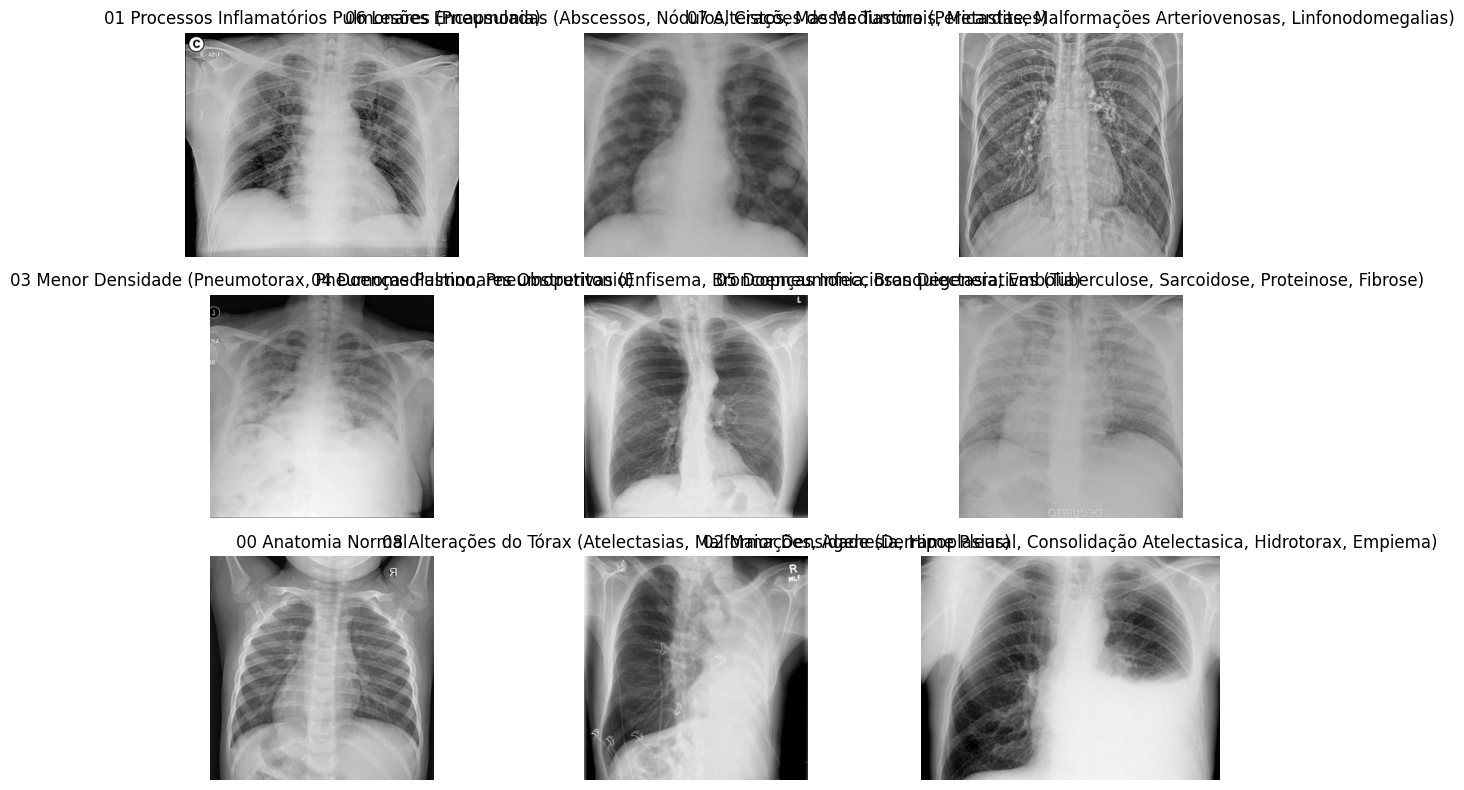

In [9]:
plt.figure(figsize=(12,8))

for i, label in enumerate(df['label'].unique()[:9]):
    img_path = random.choice(df[df['label']==label]['filepath'].values)
    img = cv2.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

Split Data

In [10]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

Parameters

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

Feature Engineering (Augmentation)

In [12]:
train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,
    rotation_range=15,       # زود من 10
    zoom_range=0.15,         # زود من 0.1
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],  # زود النطاق
    shear_range=0.1,         # ← جديد
    width_shift_range=0.1,   # ← جديد
    height_shift_range=0.1   # ← جديد
)
eval_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess
)

Generators

In [13]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE
)

val_gen = eval_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = eval_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4720 validated image filenames belonging to 9 classes.
Found 1011 validated image filenames belonging to 9 classes.
Found 1012 validated image filenames belonging to 9 classes.


Class Weights

In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

class_weight_dict = dict(enumerate(class_weights))

# زوّد وزن class 01 (Pneumonia) بشكل صريح
pneumonia_class_name = [c for c in train_gen.class_indices.keys() if c.startswith("01 ")][0]
pneumonia_idx = train_gen.class_indices[pneumonia_class_name]

class_weight_dict[pneumonia_idx] *= 1.5

print("Pneumonia class:", pneumonia_class_name)
print("Pneumonia index:", pneumonia_idx)
print("Class weights:", class_weight_dict)

Pneumonia class: 01 Processos Inflamatórios Pulmonares (Pneumonia)
Pneumonia index: 1
Class weights: {0: np.float64(0.5591092158256338), 1: np.float64(1.060197663971249), 2: np.float64(1.1064228785747774), 3: np.float64(1.1919191919191918), 4: np.float64(1.1628479921162849), 5: np.float64(1.2606837606837606), 6: np.float64(1.1376235237406604), 7: np.float64(1.2576605382360777), 8: np.float64(1.3764946048410616)}


In [15]:
print(train_gen.class_indices)
print(len(train_gen.class_indices))

{'00 Anatomia Normal': 0, '01 Processos Inflamatórios Pulmonares (Pneumonia)': 1, '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)': 2, '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)': 3, '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)': 4, '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)': 5, '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)': 6, '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)': 7, '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)': 8}
9


Build Model

In [16]:
def build_model(num_classes):
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs=base_model.input, outputs=outputs)

num_classes = len(train_gen.class_indices)

model = build_model(num_classes)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,384,940 (16.73 MB)

 Trainable params: 332,809 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

early stopping

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

Training

In [18]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weight_dict
)

Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.2315 - loss: 2.8757
Epoch 1: val_accuracy improved from None to 0.60138, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 146s 744ms/step - accuracy: 0.3161 - loss: 2.4836 - val_accuracy: 0.6014 - val_loss: 1.4414
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.4757 - loss: 1.7038
Epoch 2: val_accuracy improved from 0.60138 to 0.71612, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 481ms/step - accuracy: 0.4979 - loss: 1.6426 - val_accuracy: 0.7161 - val_loss: 1.0129
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.5612 - loss: 1.4503
Epoch 3: val_accuracy improved from 0.71612 to 0.74876, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 489ms/step - accuracy: 0.5739 - loss: 1.3713 - val_accuracy: 0.7488 - val_loss: 0.8007
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.6281 - loss: 1.2076
Epoch 4: val_accuracy improved from 0.74876 to 0.78734, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 485ms/step - accuracy: 0.6333 - loss: 1.1893 - val_accuracy: 0.7873 - val_loss: 0.6807
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.6577 - loss: 1.0784
Epoch 5: val_accuracy improved from 0.78734 to 0.81207, saving model to best_model.h5


...


Epoch 22: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 483ms/step - accuracy: 0.8487 - loss: 0.4780 - val_accuracy: 0.9377 - val_loss: 0.2439
Epoch 23/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8561 - loss: 0.4701
Epoch 23: val_accuracy improved from 0.93769 to 0.94263, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 493ms/step - accuracy: 0.8489 - loss: 0.4800 - val_accuracy: 0.9426 - val_loss: 0.2334
Epoch 24/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8586 - loss: 0.4321
Epoch 24: val_accuracy did not improve from 0.94263
148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 490ms/step - accuracy: 0.8470 - loss: 0.4646 - val_accuracy: 0.9367 - val_loss: 0.2333
Epoch 25/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8577 - loss: 0.4371
Epoch 25: val_accuracy did not improve from 0.94263
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 485ms/step - accuracy: 0.8587 - loss: 0.4409 - val_accuracy: 0.9416 - val_loss: 0.2201
Epoch 26/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8554 - loss: 0.4483
Epoch 26: val_accuracy improved from 0.94263 to 0.94560, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 477ms/step - accuracy: 0.8536 - loss: 0.4465 - val_accuracy: 0.9456 - val_loss: 0.2077
Epoch 27/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8630 - loss: 0.4203
Epoch 27: val_accuracy did not improve from 0.94560
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 477ms/step - accuracy: 0.8623 - loss: 0.4205 - val_accuracy: 0.9456 - val_loss: 0.2101
Epoch 28/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8650 - loss: 0.4274
Epoch 28: val_accuracy did not improve from 0.94560
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 478ms/step - accuracy: 0.8672 - loss: 0.4123 - val_accuracy: 0.9446 - val_loss: 0.2040
Epoch 29/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8801 - loss: 0.3809
Epoch 29: val_accuracy improved from 0.94560 to 0.94758, saving model to best_model.h5



Epoch 29: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 488ms/step - accuracy: 0.8669 - loss: 0.4043 - val_accuracy: 0.9476 - val_loss: 0.1908
Epoch 30/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8813 - loss: 0.3910
Epoch 30: val_accuracy improved from 0.94758 to 0.95549, saving model to best_model.h5



Epoch 30: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 477ms/step - accuracy: 0.8794 - loss: 0.3909 - val_accuracy: 0.9555 - val_loss: 0.1885


Fine-Tuning

In [19]:
import tensorflow as tf
for layer in model.layers:
    layer.trainable = False
for layer in model.layers[-5:]:
    layer.trainable = True
for layer in model.layers[-35:-5]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

print("Trainable layers:", sum(layer.trainable for layer in model.layers))
print("Total layers:", len(model.layers))

Trainable layers: 28
Total layers: 243


In [20]:
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy()

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

In [21]:
fine_checkpoint = ModelCheckpoint(
    'best_model_finetuned.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, fine_checkpoint],
    class_weight=class_weight_dict
)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.8799 - loss: 0.0546
Epoch 1: val_accuracy improved from None to 0.95747, saving model to best_model_finetuned.h5



Epoch 1: finished saving model to best_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 123s 649ms/step - accuracy: 0.8782 - loss: 0.0546 - val_accuracy: 0.9575 - val_loss: 0.0211
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8792 - loss: 0.0497
Epoch 2: val_accuracy did not improve from 0.95747
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 481ms/step - accuracy: 0.8824 - loss: 0.0485 - val_accuracy: 0.9555 - val_loss: 0.0206
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.8831 - loss: 0.0487
Epoch 3: val_accuracy did not improve from 0.95747
148/148 ━━━━━━━━━━━━━━━━━━━━ 69s 469ms/step - accuracy: 0.8869 - loss: 0.0477 - val_accuracy: 0.9555 - val_loss: 0.0196
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8889 - loss: 0.0464
Epoch 4: val_accuracy improved from 0.95747 to 0.95846, saving model to best_model_finetuned.h5



Epoch 4: finished saving model to best_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 486ms/step - accuracy: 0.8854 - loss: 0.0482 - val_accuracy: 0.9585 - val_loss: 0.0192
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8846 - loss: 0.0478
Epoch 5: val_accuracy improved from 0.95846 to 0.96044, saving model to best_model_finetuned.h5



Epoch 5: finished saving model to best_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 487ms/step - accuracy: 0.8883 - loss: 0.0454 - val_accuracy: 0.9604 - val_loss: 0.0182
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.8895 - loss: 0.0438
Epoch 6: val_accuracy did not improve from 0.96044
148/148 ━━━━━━━━━━━━━━━━━━━━ 95s 640ms/step - accuracy: 0.8886 - loss: 0.0445 - val_accuracy: 0.9575 - val_loss: 0.0183
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8933 - loss: 0.0419
Epoch 7: val_accuracy did not improve from 0.96044
148/148 ━━━━━━━━━━━━━━━━━━━━ 122s 506ms/step - accuracy: 0.8915 - loss: 0.0442 - val_accuracy: 0.9545 - val_loss: 0.0180
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8903 - loss: 0.0438
Epoch 8: val_accuracy did not improve from 0.96044
148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 480ms/step - accuracy: 0.8843 - loss: 0.0449 - val_accuracy: 0.9604 - val_loss: 0.0166
Epoch 9/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 

Evaluation

In [22]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 461ms/step - accuracy: 0.9615 - loss: 0.0167
Test Accuracy: 0.9614624381065369


Accuracy Curve

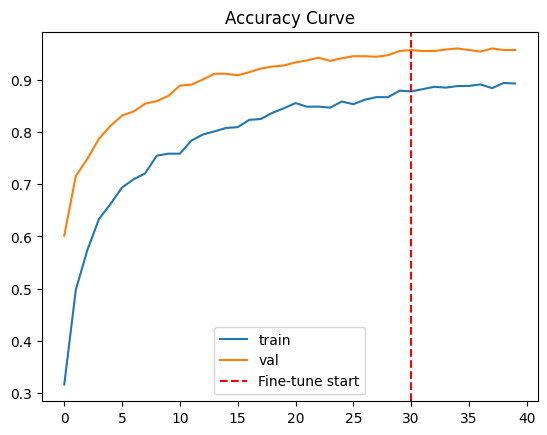

In [23]:
all_acc = history.history['accuracy'] + history_fine.history['accuracy']
all_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']


plt.plot(all_acc, label='train')
plt.plot(all_val_acc, label='val')
plt.axvline(x=len(history.history['accuracy']), color='red', linestyle='--', label='Fine-tune start')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Confusion Matrix

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step


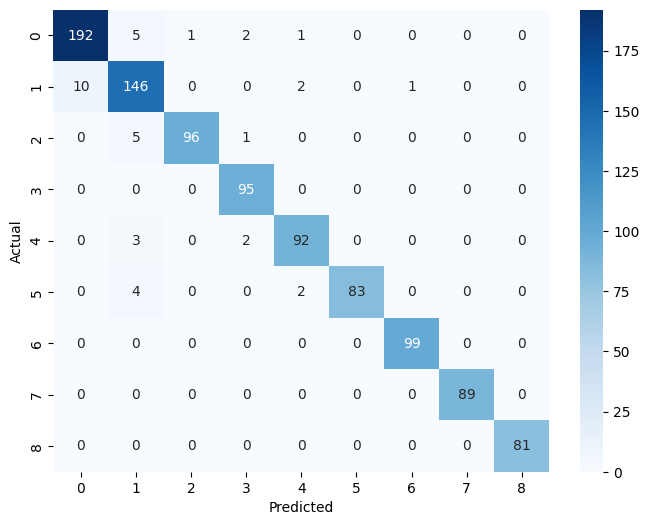

In [24]:
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [25]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal       0.95      0.96      0.95       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)       0.90      0.92      0.91       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)       0.99      0.94      0.96       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)       0.95      1.00      0.97        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)       0.95      0.95      0.95        97
      05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)       1.00      0.93      0.97        89
         06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Meta

Predict Image

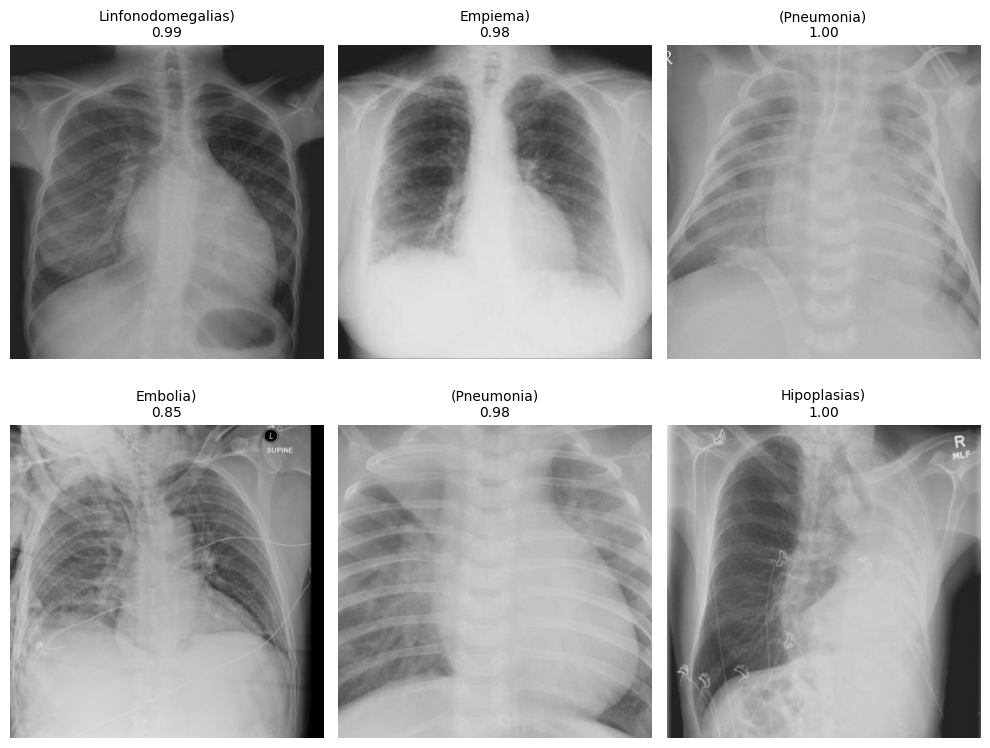

In [26]:
def predict_image(img_path):
    if not os.path.exists(img_path):
        return None, None

    img = cv2.imread(img_path)
    if img is None:
        return None, None

    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224, 224))
    img = efficientnet_preprocess(img)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)
    class_idx = np.argmax(pred)
    confidence = np.max(pred)

    class_name = list(train_gen.class_indices.keys())[class_idx]

    short_name = class_name.split(' ')[-1]

    return img_display, f"{short_name}\n{confidence:.2f}"


paths = test_df['filepath'].sample(6).values

plt.figure(figsize=(10, 8))

for i, p in enumerate(paths):
    img, title = predict_image(p)
    if img is None:
        continue

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(title, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Install + imports for LIME / SHAP

In [28]:
!pip install -q lime shap scikit-image

import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [29]:

class_names = list(train_gen.class_indices.keys())

def load_rgb_image(img_path, size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.uint8)

def preprocess_for_model(images):
    images = np.array(images).astype(np.float32)
    return efficientnet_preprocess(images.copy())

def predict_for_xai(images):
    images = preprocess_for_model(images)
    return model.predict(images, verbose=0)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

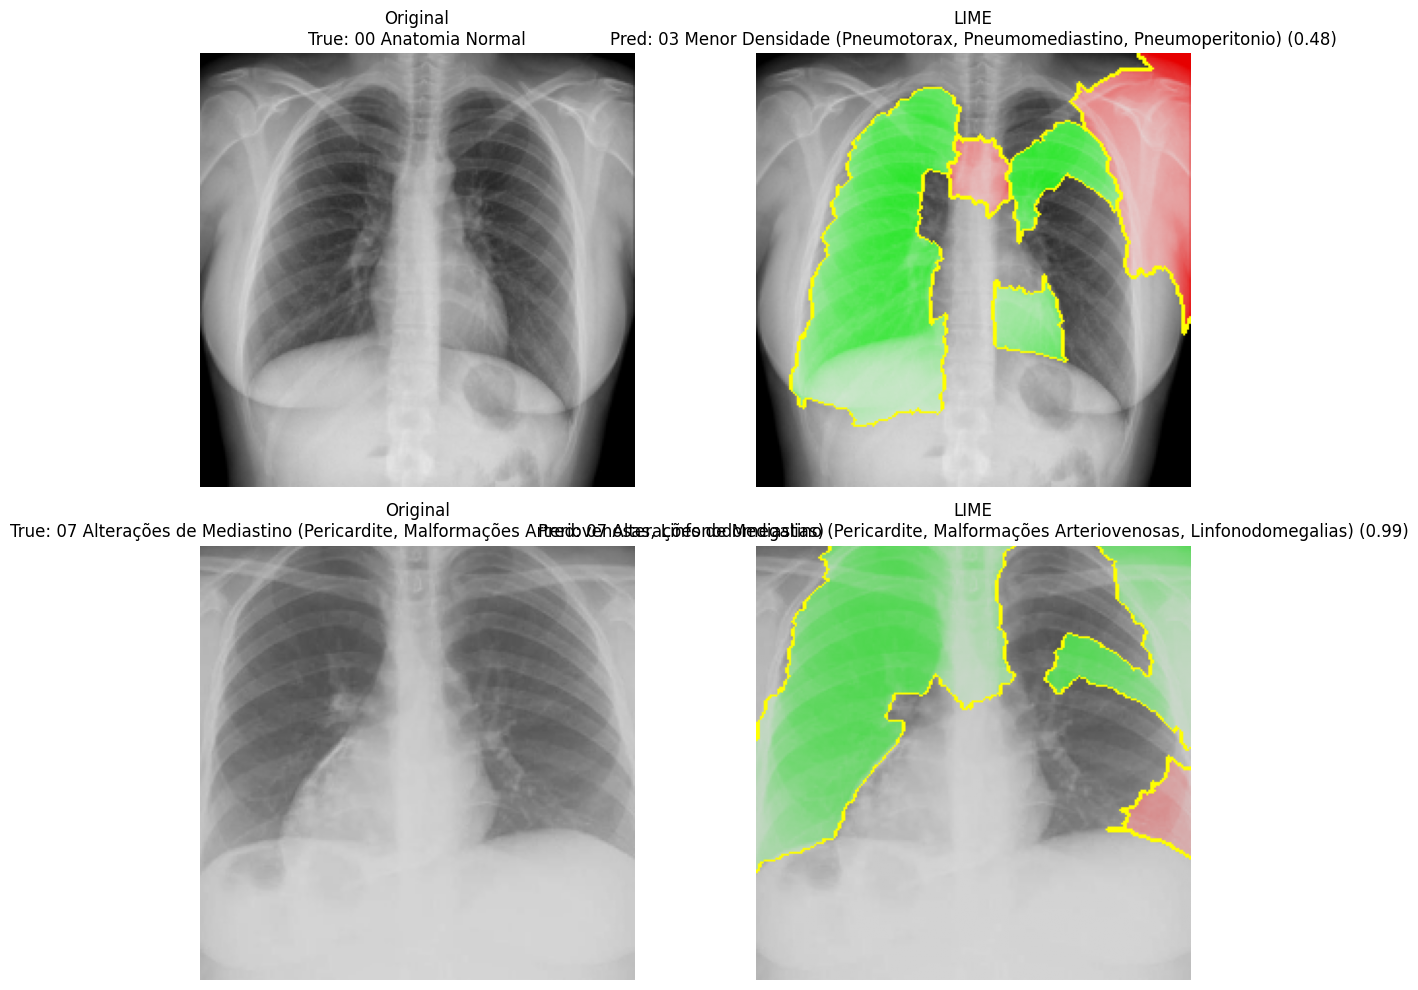

In [36]:
# LIME on 2 random test images

lime_explainer = lime_image.LimeImageExplainer()

sample_rows = test_df.sample(2, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i, row in sample_rows.iterrows():
    img_path = row["filepath"]
    true_label = row["label"]

    img = load_rgb_image(img_path)

    preds = predict_for_xai(np.expand_dims(img, axis=0))
    pred_idx = int(np.argmax(preds[0]))
    pred_label = class_names[pred_idx]
    confidence = float(preds[0][pred_idx])

    explanation = lime_explainer.explain_instance(
        image=img,
        classifier_fn=predict_for_xai,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        label=pred_idx,
        positive_only=False,
        num_features=8,
        hide_rest=False
    )

    plt.subplot(2, 2, 2*i + 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {true_label}")
    plt.axis("off")

    plt.subplot(2, 2, 2*i + 2)
    plt.imshow(mark_boundaries(lime_img / 255.0, lime_mask))
    plt.title(f"LIME\nPred: {pred_label} ({confidence:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [00:44, 22.41s/it]


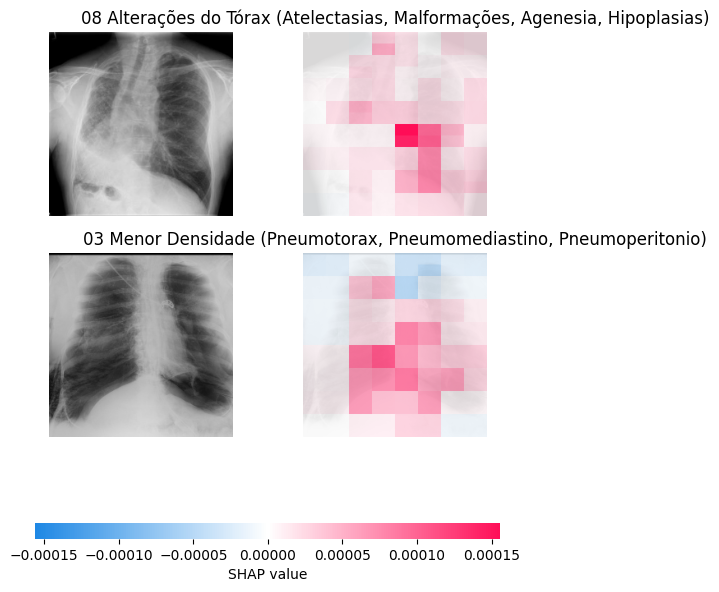

In [31]:
shap_masker = shap.maskers.Image("blur(32,32)", (IMG_SIZE, IMG_SIZE, 3))
shap_explainer = shap.Explainer(
    predict_for_xai,
    shap_masker,
    output_names=class_names
)

shap_rows = test_df.sample(2, random_state=7).reset_index(drop=True)
shap_images = np.array([load_rgb_image(p) for p in shap_rows["filepath"]])

shap_values = shap_explainer(
    shap_images,
    max_evals=300,
    batch_size=16,
    outputs=shap.Explanation.argsort.flip[:1]
)

shap.image_plot(shap_values)

In [32]:


for i, row in shap_rows.iterrows():
    img = np.expand_dims(load_rgb_image(row["filepath"]), axis=0)
    preds = predict_for_xai(img)
    pred_idx = int(np.argmax(preds[0]))
    print(f"Image {i+1} | True: {row['label']} | Pred: {class_names[pred_idx]} | Confidence: {preds[0][pred_idx]:.2f}")

Image 1 | True: 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias) | Pred: 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias) | Confidence: 1.00
Image 2 | True: 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio) | Pred: 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio) | Confidence: 0.87


 Interpretability using Grad-CAM

In [33]:
# Grad-CAM helper functions

class_names = list(train_gen.class_indices.keys())

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def get_img_array_for_gradcam(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = img.astype(np.float32)
    img_array = efficientnet_preprocess(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array, training=False)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()

def overlay_gradcam(original_img, heatmap, alpha=0.35):
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(original_img, 1 - alpha, heatmap, alpha, 0)
    return superimposed_img

last_conv_layer_name = find_last_conv_layer(model)
print("Last Conv Layer:", last_conv_layer_name)

Last Conv Layer: top_conv


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


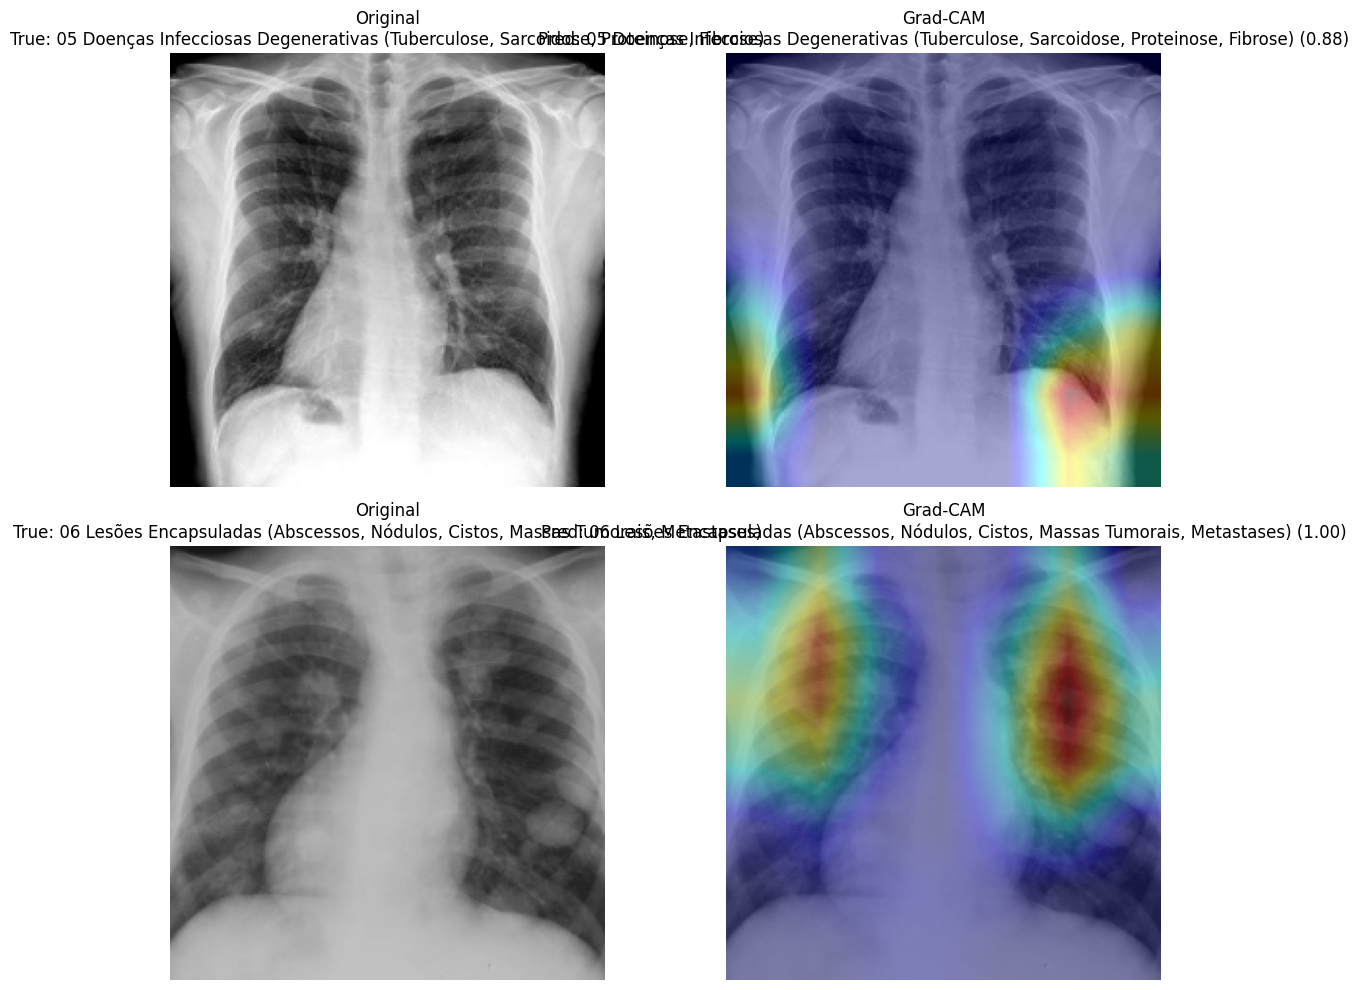

In [34]:
# Grad-CAM visualization on 2 random test images

gradcam_rows = test_df.sample(2, random_state=21).reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i, row in gradcam_rows.iterrows():
    img_path = row["filepath"]
    true_label = row["label"]

    original_img, img_array = get_img_array_for_gradcam(img_path)

    heatmap, preds = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    pred_idx = int(np.argmax(preds[0]))
    pred_label = class_names[pred_idx]
    confidence = float(preds[0][pred_idx])

    gradcam_img = overlay_gradcam(original_img, heatmap)

    plt.subplot(2, 2, 2*i + 1)
    plt.imshow(original_img, cmap="gray")
    plt.title(f"Original\nTrue: {true_label}")
    plt.axis("off")

    plt.subplot(2, 2, 2*i + 2)
    plt.imshow(gradcam_img)
    plt.title(f"Grad-CAM\nPred: {pred_label} ({confidence:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# Optional: print labels for the Grad-CAM samples

for i, row in gradcam_rows.iterrows():
    _, img_array = get_img_array_for_gradcam(row["filepath"])
    preds = model.predict(img_array, verbose=0)
    pred_idx = int(np.argmax(preds[0]))

    print(
        f"Image {i+1} | True: {row['label']} | "
        f"Pred: {class_names[pred_idx]} | "
        f"Confidence: {preds[0][pred_idx]:.2f}"
    )


Image 1 | True: 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose) | Pred: 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose) | Confidence: 0.88
Image 2 | True: 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases) | Pred: 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases) | Confidence: 1.00
